In [1]:
# Diabetes Classification Project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load Data
# Source: Pima Indians Diabetes dataset. Columns per UCI documentation.

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv("pima_diabetes.csv", header=None, names=columns)
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# EDA — Nulls, Class Balance, Distributions

print("Missing values (NaN):")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values (NaN):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


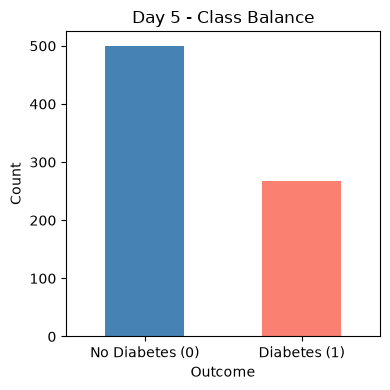

In [5]:
print("Class balance:")
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(3))

plt.figure(figsize=(4, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.xticks([0, 1], ["No Diabetes (0)", "Diabetes (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Day 5 - Class Balance")
plt.tight_layout()
plt.show()

In [6]:
# Hidden Missing Values

zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f"{col}: {zero_count} zeros ({pct:.1f}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


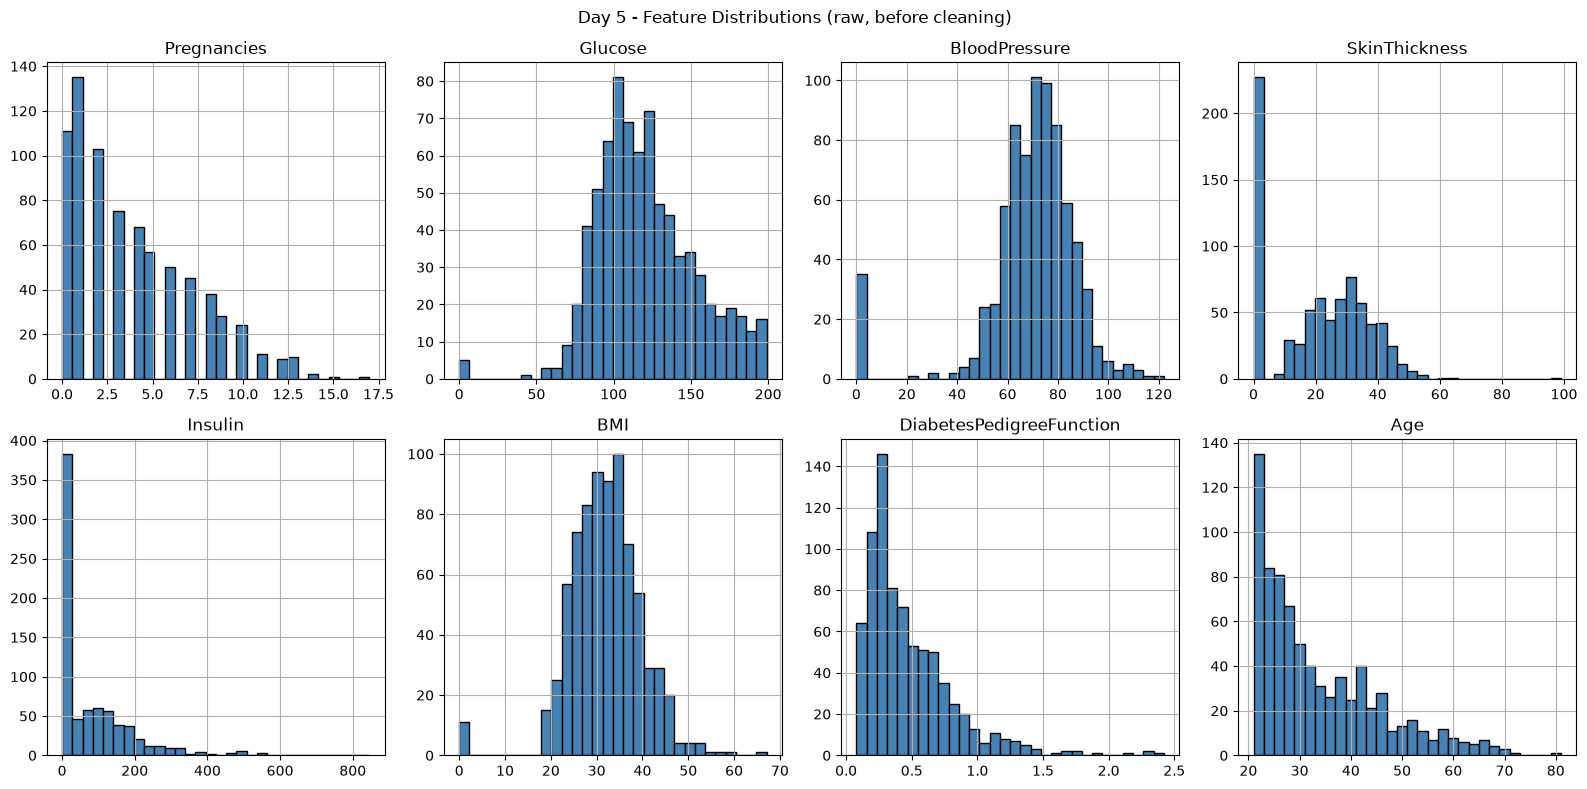

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), columns[:-1]):
    df[col].hist(ax=ax, bins=30, color="steelblue", edgecolor="black")
    ax.set_title(col)
plt.suptitle("Day 5 - Feature Distributions (raw, before cleaning)")
plt.tight_layout()
plt.show()

In [8]:
# Preprocess
# Replace biologically-impossible zeros with median (grouped by Outcome to avoid leaking class signal into imputation, then split before any fit).

df_clean = df.copy()
for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("NaNs introduced:")
print(df_clean[zero_check_cols].isnull().sum())


NaNs introduced:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [9]:
# Train-Test Split (before imputation to prevent leakage)

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (614, 8) Test shape: (154, 8)
Train class balance:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64
Test class balance:
 Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [10]:
# Impute using TRAIN medians only, apply same values to test
train_medians = X_train[zero_check_cols].median()
print("Imputation values (train medians):")
print(train_medians)

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()
for col in zero_check_cols:
    X_train_imputed[col] = X_train_imputed[col].fillna(train_medians[col])
    X_test_imputed[col] = X_test_imputed[col].fillna(train_medians[col])

assert X_train_imputed.isnull().sum().sum() == 0
assert X_test_imputed.isnull().sum().sum() == 0
print("\nImputation complete, no nulls remain.")

Imputation values (train medians):
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.4
dtype: float64

Imputation complete, no nulls remain.


In [11]:
# Feature Scaling
# Required for KNN and SVM. Trees/RF are scale-invariant but scaling causes no harm, so apply uniformly for a clean comparable pipeline.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Keep both scaled and unscaled for tree models, which don't need scaling
X_train_trees = X_train_imputed.values
X_test_trees = X_test_imputed.values

In [12]:
# Train All 4 Models

In [13]:
# Decision Tree

from sklearn.model_selection import GridSearchCV

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [3, 4, 5, 6, 8, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    cv=5, scoring="accuracy", n_jobs=-1
)
dt_grid.fit(X_train_trees, y_train)
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test_trees)
print("DT Best Params:", dt_grid.best_params_)
print("DT Test Accuracy:", accuracy_score(y_test, dt_pred))

DT Best Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
DT Test Accuracy: 0.6883116883116883


In [14]:
# Random Forest

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [4, 6, 8, None], "max_features": ["sqrt", "log2"]},
    cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train_trees, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_trees)
print("RF Best Params:", rf_grid.best_params_)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))

RF Best Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
RF Test Accuracy: 0.7662337662337663


In [15]:
#  KNN

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": list(range(3, 25, 2)), "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
    cv=5, scoring="accuracy", n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test_scaled)
print("KNN Best Params:", knn_grid.best_params_)
print("KNN Test Accuracy:", accuracy_score(y_test, knn_pred))

KNN Best Params: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'uniform'}
KNN Test Accuracy: 0.7467532467532467


In [16]:
# SVM

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.1]},
    cv=5, scoring="accuracy", n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test_scaled)
print("SVM Best Params:", svm_grid.best_params_)
print("SVM Test Accuracy:", accuracy_score(y_test, svm_pred))

SVM Best Params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVM Test Accuracy: 0.6948051948051948


c:\Users\Bibek\Documents\AI-ML Intern\AI-ML\.conda\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
# Store Predictions for Evaluation

model_predictions = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "SVM": svm_pred
}

model_objects = {
    "Decision Tree": dt_best,
    "Random Forest": rf_best,
    "KNN": knn_best,
    "SVM": svm_best
}

quick_check = pd.DataFrame({
    "Model": list(model_predictions.keys()),
    "Test Accuracy": [accuracy_score(y_test, p) for p in model_predictions.values()]
}).sort_values("Test Accuracy", ascending=False)
quick_check

,Model,Test Accuracy
1,Random Forest,0.766234
2,KNN,0.746753
3,SVM,0.694805
0,Decision Tree,0.688312
